In [3]:
import tensorflow as tf
from tensorflow.keras.applications import (
    VGG16, ResNet50, DenseNet121, MobileNetV2, EfficientNetB0, InceptionV3, Xception
)
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import os
import json
import numpy as np

# Define constants
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 30
MODELS = ['xception', 'vgg16', 'resnet50', 'googlenet', 'mobilenet', 'densenet', 'lenet', 'alexnet']
MODELS = ['resnet50']

# Directories for datasets
train_dir = "img_bk/train"
val_dir = "img_bk/validate"
test_dir = "img_bk/test"

# Load the datasets
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'  # Ensure integer labels (0: PASS, 1: FAIL)
)
val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

# Optional: Cache and prefetch for performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Function to create a custom classification model for binary classification (PASS, FAIL)
def create_model(base_model):
    base_model.trainable = False  # Freeze the base model
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)  # Add a dense layer
    outputs = Dense(1, activation='sigmoid')(x)  # Binary output layer (sigmoid for binary classification)
    model = Model(inputs=base_model.input, outputs=outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Function to create LeNet model accepting RGB images for binary classification
def create_lenet():
    model = tf.keras.Sequential([
        Conv2D(6, kernel_size=(5, 5), activation='relu', input_shape=(224, 224, 3)),
        MaxPooling2D(),
        Conv2D(16, kernel_size=(5, 5), activation='relu'),
        MaxPooling2D(),
        Flatten(),
        Dense(120, activation='relu'),
        Dense(84, activation='relu'),
        Dense(1, activation='sigmoid')  # Binary output layer for PASS/FAIL
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Update the train_save_model function with early stopping
def train_save_model(model, model_name):
    print(f"\nTraining {model_name}...")
    
    # Train the model with early stopping
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        callbacks=[early_stopping]  # Pass the early stopping callback here
    )
    
    # Extract history data to a JSON-serializable format
    history_serialized = {key: value for key, value in history.history.items()}

    # Save the model in HDF5 format
    model_save_path = f'{model_name}_model_all_2class_img_bk_plot.h5'
    model.save(model_save_path)  # Use Keras save method
    print(f"{model_name} saved at {model_save_path}")

    return history_serialized  # Return the serialized history


# Function to evaluate model on the test set
def evaluate_model(model, model_name):
    test_loss, test_acc = model.evaluate(test_dataset)
    print(f'{model_name} Test accuracy: {test_acc}')
    return test_acc

# Dictionary to store model accuracies and histories
model_accuracies = {}
all_histories = {}

# Train and evaluate models
for model_name in MODELS:
    if model_name == 'lenet':
        model = create_lenet()  # Create LeNet model
    
    elif model_name == 'alexnet':
        # Create AlexNet model from scratch
        model = tf.keras.Sequential([
            Conv2D(96, (11, 11), strides=4, activation='relu', input_shape=(224, 224, 3)),
            MaxPooling2D((3, 3), strides=2),
            Conv2D(256, (5, 5), padding='same', activation='relu'),
            MaxPooling2D((3, 3), strides=2),
            Conv2D(384, (3, 3), padding='same', activation='relu'),
            Conv2D(384, (3, 3), padding='same', activation='relu'),
            Conv2D(256, (3, 3), padding='same', activation='relu'),
            MaxPooling2D((3, 3), strides=2),
            Flatten(),
            Dense(4096, activation='relu'),
            Dense(4096, activation='relu'),
            Dense(1, activation='sigmoid')  # Binary output for PASS/FAIL
        ])
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    elif model_name == 'googlenet':
        base_model = InceptionV3(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
        model = create_model(base_model)
    
    elif model_name == 'mobilenet':
        base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
        model = create_model(base_model)
    
    elif model_name == 'vgg16':
        base_model = VGG16(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
        model = create_model(base_model)
    
    elif model_name == 'resnet50':
        base_model = ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
        model = create_model(base_model)
    
    elif model_name == 'densenet':
        base_model = DenseNet121(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
        model = create_model(base_model)
    
    elif model_name == 'efficientnet':
        base_model = EfficientNetB0(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
        model = create_model(base_model)

    elif model_name == 'xception':
        base_model = Xception(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
        model = create_model(base_model)

    # Train, save and evaluate the model
    history = train_save_model(model, model_name)
    accuracy = evaluate_model(model, model_name)
    
    # Store accuracy and history
    model_accuracies[model_name] = accuracy
    all_histories[model_name] = history  # Store serialized history

# Save all histories to one JSON file
with open('all_histories_2class.json', 'w') as f:
    json.dump(all_histories, f)

# Print final accuracy comparison
print("\nAccuracy comparison:")
for model_name, accuracy in model_accuracies.items():
    print(f"{model_name}: {accuracy:.4f}")


Found 8856 files belonging to 2 classes.
Found 1476 files belonging to 2 classes.
Found 1477 files belonging to 2 classes.

Training resnet50...
Epoch 1/30
554/554 [==============================] - 80s 58ms/step - loss: 0.7778 - accuracy: 0.5491 - val_loss: 0.6545 - val_accuracy: 0.5637
Epoch 2/30
554/554 [==============================] - 30s 54ms/step - loss: 0.6589 - accuracy: 0.5892 - val_loss: 0.6380 - val_accuracy: 0.6192
Epoch 3/30
554/554 [==============================] - 30s 55ms/step - loss: 0.6470 - accuracy: 0.6009 - val_loss: 0.6345 - val_accuracy: 0.6064
Epoch 4/30
554/554 [==============================] - 30s 55ms/step - loss: 0.6419 - accuracy: 0.6099 - val_loss: 0.6797 - val_accuracy: 0.5332
Epoch 5/30
554/554 [==============================] - 30s 55ms/step - loss: 0.6372 - accuracy: 0.6039 - val_loss: 0.6259 - val_accuracy: 0.6186
Epoch 6/30
554/554 [==============================] - 31s 55ms/step - loss: 0.6354 - accuracy: 0.6096 - val_loss: 0.6298 - val_accuracy

In [2]:
import pandas as pd
pd.read_json('all_histories_2class.json')

,xception,vgg16,resnet50,googlenet,mobilenet,densenet,lenet,alexnet
loss,"[1.0363324880599971, 0.6871460080146791, 0.645...","[0.8343060016632081, 0.7037861347198481, 0.666...","[0.7569746971130371, 0.651926398277282, 0.6462...","[2.197412252426147, 0.730304419994354, 0.66362...","[0.729810297489166, 0.678892791271209, 0.67527...","[2.104427814483642, 1.142736077308654, 0.80855...","[4.837533473968506, 0.6248125433921811, 0.6219...","[14.921947479248047, 0.693059206008911, 0.6930..."
accuracy,"[0.56854110956192, 0.5934959053993221, 0.59767...","[0.560411036014556, 0.5958672165870661, 0.6015...","[0.562669396400451, 0.595302641391754, 0.60015...","[0.553635954856872, 0.5776874423027031, 0.5878...","[0.5509259104728691, 0.5630081295967101, 0.569...","[0.530261993408203, 0.5324074029922481, 0.5575...","[0.587285459041595, 0.633017182350158, 0.62240...","[0.500451683998107, 0.510162591934204, 0.51016..."
val_loss,"[0.6446675658226011, 0.6953331828117371, 0.637...","[0.6661084294319151, 0.619517564773559, 0.6687...","[0.7133464813232421, 0.6358178853988641, 0.626...","[0.628586649894714, 0.8127368688583371, 0.6289...","[0.6729572415351861, 0.675236463546752, 0.6678...","[1.418350338935852, 1.624824047088623, 0.72721...","[0.605351448059082, 0.633927822113037, 0.62228...","[0.693158388137817, 0.693384230136871, 0.69320..."
val_accuracy,"[0.611788630485534, 0.5372628569602961, 0.5840...","[0.6023035049438471, 0.6131436228752131, 0.598...","[0.508807599544525, 0.598238468170166, 0.62195...","[0.6192411780357361, 0.5013549923896791, 0.602...","[0.539295375347137, 0.591463387012481, 0.59620...","[0.5081300735473631, 0.5006775259971611, 0.586...","[0.64363145828247, 0.5928184390068051, 0.61720...","[0.49932250380516, 0.49932250380516, 0.4993225..."


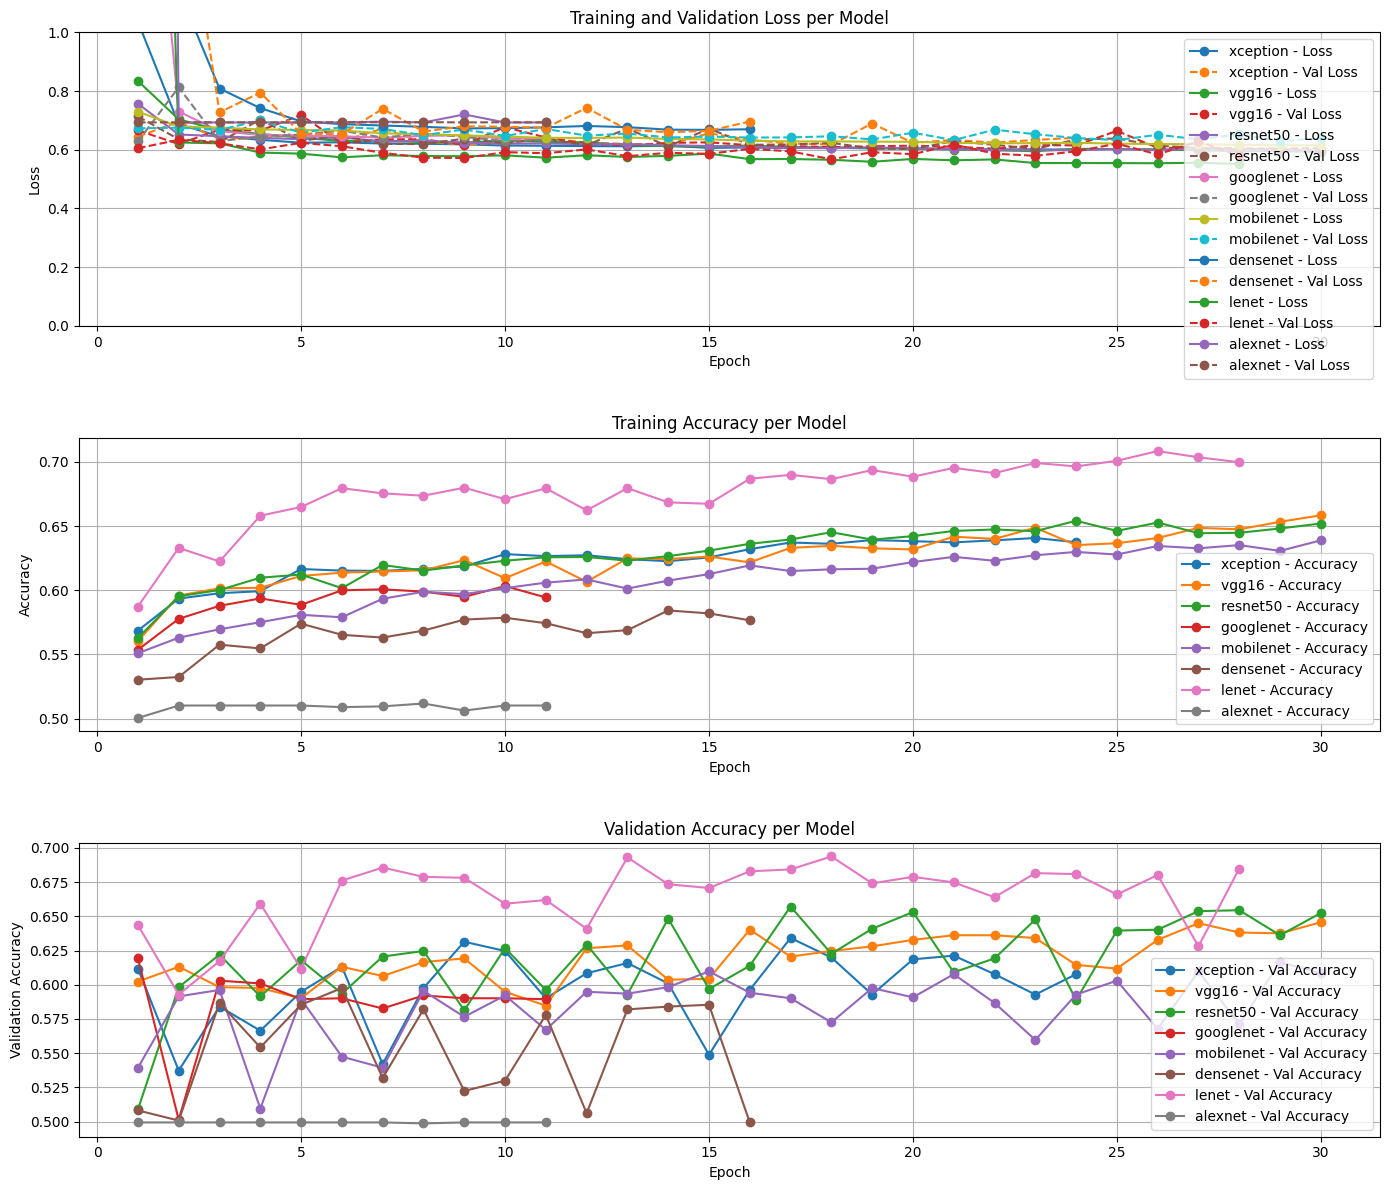

In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Define the path to your JSON file
json_file_path = 'all_histories_2class.json'

# Open and read the JSON file
with open(json_file_path, 'r') as file:
    results = json.load(file)

# List of models
MODELS = ['xception', 'vgg16', 'resnet50', 'googlenet', 'mobilenet', 'densenet', 'lenet', 'alexnet']

# Prepare data for DataFrame
data = {
    "Model": [],
    "Epoch": [],
    "Loss": [],
    "Accuracy": [],
    "Val_Loss": [],
    "Val_Accuracy": []
}

# Populate the data dictionary
for model in MODELS:
    if model in results:
        epochs = range(1, len(results[model]['loss']) + 1)  # Assuming the number of entries in loss corresponds to epochs
        for epoch in epochs:
            data["Model"].append(model)
            data["Epoch"].append(epoch)
            data["Loss"].append(results[model]['loss'][epoch - 1])
            data["Accuracy"].append(results[model]['accuracy'][epoch - 1])
            data["Val_Loss"].append(results[model]['val_loss'][epoch - 1])
            data["Val_Accuracy"].append(results[model]['val_accuracy'][epoch - 1])
    else:
        print(f"No results found for {model}.")

# Create the DataFrame
df = pd.DataFrame(data)

# Set up the plot
plt.figure(figsize=(14, 12))

# Plot Loss
plt.subplot(3, 1, 1)
for model in MODELS:
    model_data = df[df['Model'] == model]
    plt.plot(model_data['Epoch'], model_data['Loss'], marker='o', label=f"{model} - Loss")
    plt.plot(model_data['Epoch'], model_data['Val_Loss'], marker='o', linestyle='--', label=f"{model} - Val Loss")

plt.title('Training and Validation Loss per Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0, 1)  # Set the y-axis limits between 0 and 1
plt.legend()
plt.grid(True)


# Plot Accuracy
plt.subplot(3, 1, 2)
for model in MODELS:
    model_data = df[df['Model'] == model]
    plt.plot(model_data['Epoch'], model_data['Accuracy'], marker='o', label=f"{model} - Accuracy")

plt.title('Training Accuracy per Model')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Validation Accuracy
plt.subplot(3, 1, 3)
for model in MODELS:
    model_data = df[df['Model'] == model]
    plt.plot(model_data['Epoch'], model_data['Val_Accuracy'], marker='o', label=f"{model} - Val Accuracy")

plt.title('Validation Accuracy per Model')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


In [1]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import classification_report

# Directories for dataset
test_dir = "img_bk/test"

# Load the test dataset
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

# Retrieve class names directly from the dataset
class_names = test_dataset.class_names

# Cache and prefetch test dataset for performance
AUTOTUNE = tf.data.AUTOTUNE
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# Function to get true labels and predictions
def get_predictions_and_labels(model):
    true_labels = []
    predictions = []

    for images, labels in test_dataset:
        true_labels.extend(labels.numpy())  # Add true labels
        preds = model.predict(images)
        predictions.extend((preds > 0.5).astype(int).flatten())  # Threshold for binary classification

    return np.array(true_labels), np.array(predictions)

# Function to plot confusion matrix for a model and print classification report
def plot_confusion_matrix_and_report(model, model_name):
    true_labels, predictions = get_predictions_and_labels(model)
    
    # Print classification report
    print(f"\nClassification Report for {model_name}:\n")
    print(classification_report(true_labels, predictions, target_names=class_names))
    
    # Confusion matrix
    cm = confusion_matrix(true_labels, predictions).T
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()


# Dictionary to store model accuracies
model_accuracies = {}

# Loop over each model, load it, evaluate it, and plot confusion matrix
# Loop over each model, load it, evaluate it, and plot confusion matrix and classification report
for model_name in MODELS:
    model_file = f'{model_name}_model_all_2class_img_bk.h5'  # Path to saved model file
    if os.path.exists(model_file):
        print(f"\nLoading {model_name}...")
        model = load_model(model_file)
        true_labels, predictions = get_predictions_and_labels(model)
        
        # Calculate accuracy
        accuracy = np.mean(true_labels == predictions)
        model_accuracies[model_name] = accuracy
        
        # Plot confusion matrix and print classification report
        plot_confusion_matrix_and_report(model, model_name)
    else:
        print(f"Model file {model_file} not found!")


# Plot accuracy comparison
def plot_accuracy_comparison(model_accuracies):
    model_names = list(model_accuracies.keys())
    accuracies = list(model_accuracies.values())

    plt.figure(figsize=(10, 6))
    plt.barh(model_names, accuracies, color='skyblue')
    plt.xlabel('Accuracy')
    plt.title('Model Accuracy Comparison')
    plt.xlim(0, 1)
    
    # Add accuracy labels
    for i, v in enumerate(accuracies):
        plt.text(v, i, f"{v:.4f}", color='blue', va='center')
    
    plt.show()

# Plot final accuracy comparison chart
plot_accuracy_comparison(model_accuracies)


NameError: name 'IMG_SIZE' is not defined

Found 1477 files belonging to 2 classes.

Loading xception...
1/1 [==============================] - 0s 27ms/step

Loading vgg16...
1/1 [==============================] - 0s 25ms/step

Loading resnet50...
1/1 [==============================] - 0s 31ms/step

Loading googlenet...
1/1 [==============================] - 0s 33ms/step

Loading mobilenet...
1/1 [==============================] - 0s 25ms/step

Loading densenet...
1/1 [==============================] - 0s 35ms/step

Loading lenet...
1/1 [==============================] - 0s 25ms/step

Loading alexnet...
1/1 [==============================] - 0s 27ms/step


c:\Users\1000305259\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\1000305259\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\1000305259\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_

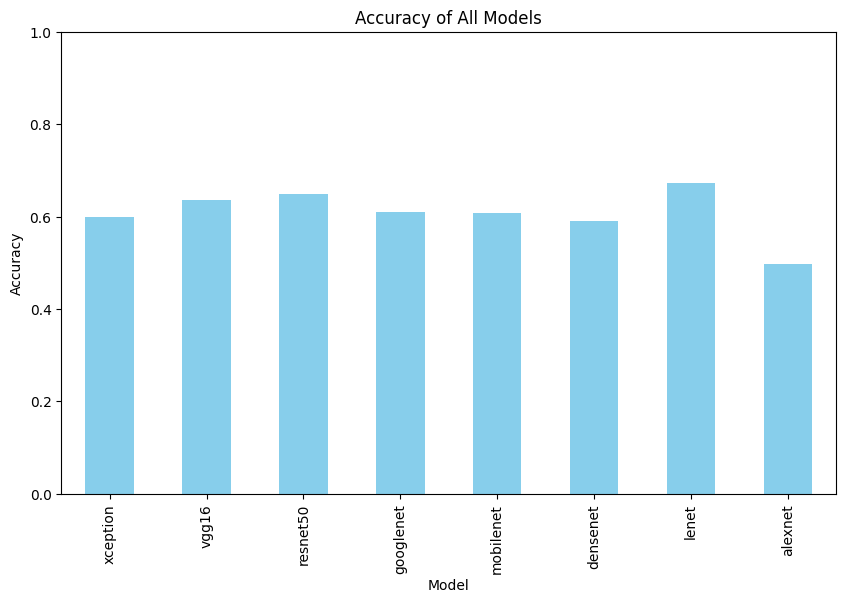

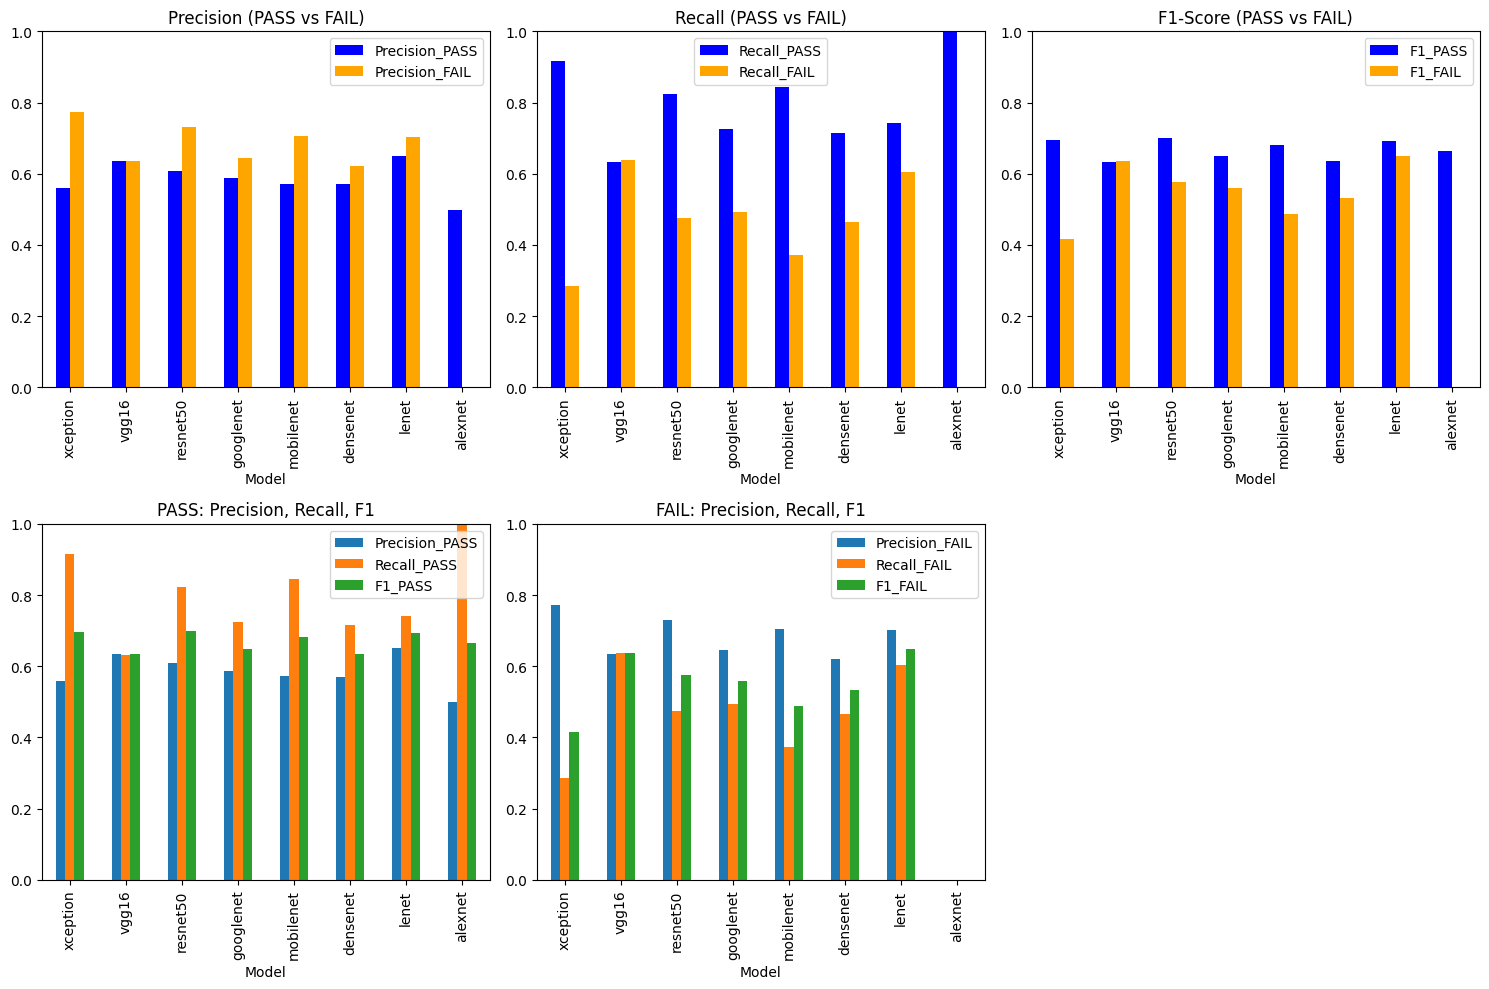

KeyError: "None of ['Model'] are in the columns"

In [14]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# Directories for dataset
test_dir = "img_bk/test"

# Load the test dataset
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

# Use class names "PASS" for 0 and "FAIL" for 1
class_names = ["PASS", "FAIL"]

# Cache and prefetch test dataset for performance
AUTOTUNE = tf.data.AUTOTUNE
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# Function to get true labels and predictions
def get_predictions_and_labels(model):
    true_labels = []
    predictions = []

    for images, labels in test_dataset:
        true_labels.extend(labels.numpy())  # Add true labels
        preds = model.predict(images)
        predictions.extend((preds > 0.5).astype(int).flatten())  # Threshold for binary classification

    return np.array(true_labels), np.array(predictions)

# Function to generate classification report for each model
def get_classification_metrics(model):
    true_labels, predictions = get_predictions_and_labels(model)
    report = classification_report(true_labels, predictions, target_names=class_names, output_dict=True)
    
    # Calculate accuracy
    accuracy = accuracy_score(true_labels, predictions)
    
    # Return precision, recall, f1-score, and accuracy as a dictionary for both classes
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision_PASS': report["PASS"]["precision"],
        'Recall_PASS': report["PASS"]["recall"],
        'F1_PASS': report["PASS"]["f1-score"],
        'Precision_FAIL': report["FAIL"]["precision"],
        'Recall_FAIL': report["FAIL"]["recall"],
        'F1_FAIL': report["FAIL"]["f1-score"],
    }

# Dictionary to store model metrics
model_metrics = []

# Loop over each model, load it, and generate classification metrics
for model_name in MODELS:
    model_file = f'{model_name}_model_all_2class_img_bk.h5'  # Path to saved model file
    if os.path.exists(model_file):
        print(f"\nLoading {model_name}...")
        model = load_model(model_file)
        
        # Get metrics for the model
        metrics = get_classification_metrics(model)
        model_metrics.append(metrics)
    else:
        print(f"Model file {model_file} not found!")

# Convert metrics to a DataFrame for easy plotting
metrics_df = pd.DataFrame(model_metrics)

# Function to plot metrics comparison for all models
def plot_metrics_comparison(metrics_df):
    metrics_df.set_index('Model', inplace=True)
    
    # Plot Accuracy
    metrics_df['Accuracy'].plot(kind='bar', figsize=(10, 6), color='skyblue', label='Accuracy', ylim=(0, 1))
    plt.title('Accuracy of All Models')
    plt.ylabel('Accuracy')
    plt.show()

    # Plot precision, recall, and f1-score for PASS and FAIL
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    metrics_df[['Precision_PASS', 'Precision_FAIL']].plot(kind='bar', ax=axes[0, 0], color=['blue', 'orange'], ylim=(0, 1))
    axes[0, 0].set_title('Precision (PASS vs FAIL)')
    
    metrics_df[['Recall_PASS', 'Recall_FAIL']].plot(kind='bar', ax=axes[0, 1], color=['blue', 'orange'], ylim=(0, 1))
    axes[0, 1].set_title('Recall (PASS vs FAIL)')
    
    metrics_df[['F1_PASS', 'F1_FAIL']].plot(kind='bar', ax=axes[0, 2], color=['blue', 'orange'], ylim=(0, 1))
    axes[0, 2].set_title('F1-Score (PASS vs FAIL)')
    
    metrics_df[['Precision_PASS', 'Recall_PASS', 'F1_PASS']].plot(kind='bar', ax=axes[1, 0], ylim=(0, 1))
    axes[1, 0].set_title('PASS: Precision, Recall, F1')
    
    metrics_df[['Precision_FAIL', 'Recall_FAIL', 'F1_FAIL']].plot(kind='bar', ax=axes[1, 1], ylim=(0, 1))
    axes[1, 1].set_title('FAIL: Precision, Recall, F1')

    axes[1, 2].axis('off')  # Empty subplot for layout balance
    
    plt.tight_layout()
    plt.show()

# Plot final metrics comparison chart
plot_metrics_comparison(metrics_df)
# Function to plot accuracy, precision, recall, and F1-score in one chart
def plot_combined_metrics(metrics_df):
    metrics_df.set_index('Model', inplace=True)

    # Extract relevant columns for the combined plot
    combined_metrics = metrics_df[['Accuracy', 
                                   'Precision_PASS', 'Recall_PASS', 'F1_PASS',
                                   'Precision_FAIL', 'Recall_FAIL', 'F1_FAIL']]

    # Plot the combined metrics as a grouped bar chart
    combined_metrics.plot(kind='bar', figsize=(12, 8), ylim=(0, 1))
    
    # Set titles and labels
    plt.title('Model Comparison: Accuracy, Precision, Recall, and F1-Score')
    plt.ylabel('Score')
    plt.xlabel('Models')
    plt.xticks(rotation=45)
    plt.legend(loc='best')
    
    # Display the plot
    plt.tight_layout()
    plt.show()

# Plot the combined metrics comparison chart
plot_combined_metrics(metrics_df)



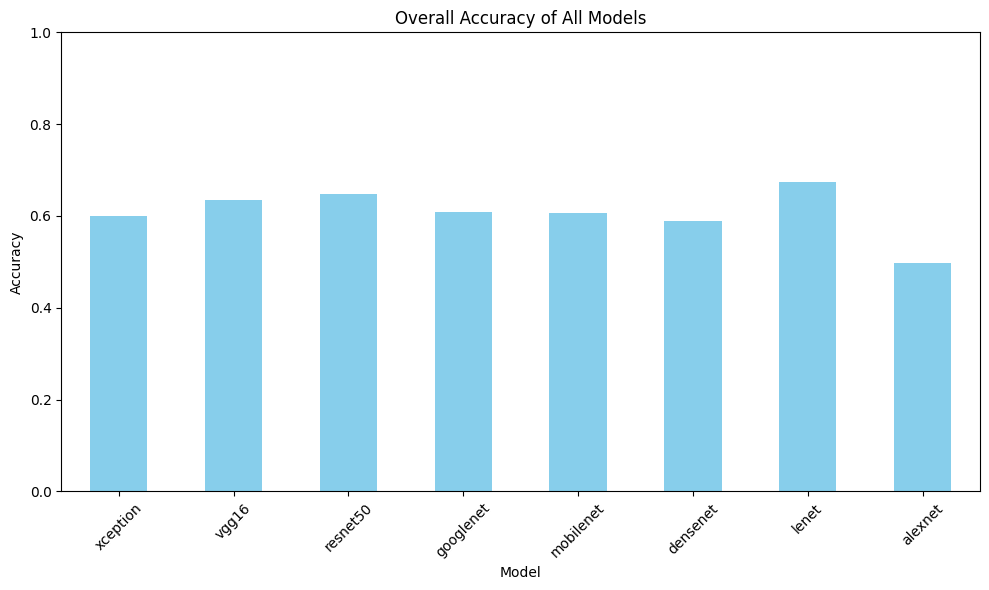

<Figure size 1000x600 with 0 Axes>

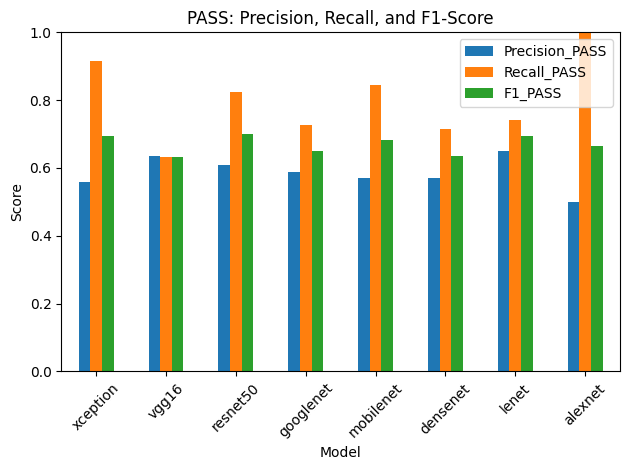

<Figure size 1000x600 with 0 Axes>

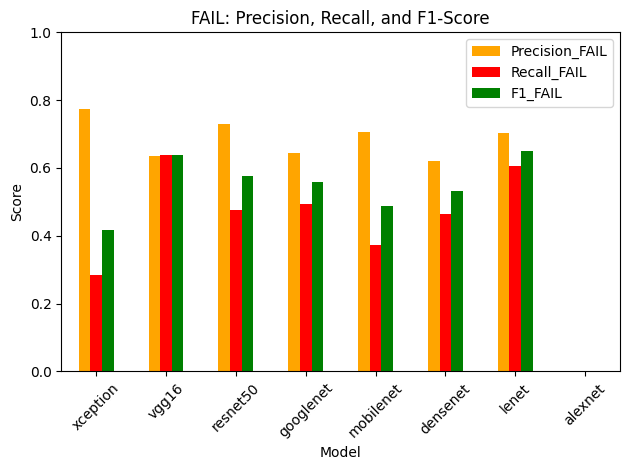

In [17]:
# Function to plot PASS, FAIL, and overall accuracy in separate charts
def plot_separate_metrics(metrics_df):
    # metrics_df.set_index('Model', inplace=True)
    
    # Plot accuracy
    plt.figure(figsize=(10, 6))
    metrics_df['Accuracy'].plot(kind='bar', color='skyblue', ylim=(0, 1))
    plt.title('Overall Accuracy of All Models')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Plot precision, recall, and F1 for PASS class
    plt.figure(figsize=(10, 6))
    metrics_df[['Precision_PASS', 'Recall_PASS', 'F1_PASS']].plot(kind='bar', ylim=(0, 1))
    plt.title('PASS: Precision, Recall, and F1-Score')
    plt.ylabel('Score')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Plot precision, recall, and F1 for FAIL class
    plt.figure(figsize=(10, 6))
    metrics_df[['Precision_FAIL', 'Recall_FAIL', 'F1_FAIL']].plot(kind='bar', ylim=(0, 1), color=['orange', 'red', 'green'])
    plt.title('FAIL: Precision, Recall, and F1-Score')
    plt.ylabel('Score')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Call the function to plot separate charts
plot_separate_metrics(metrics_df)


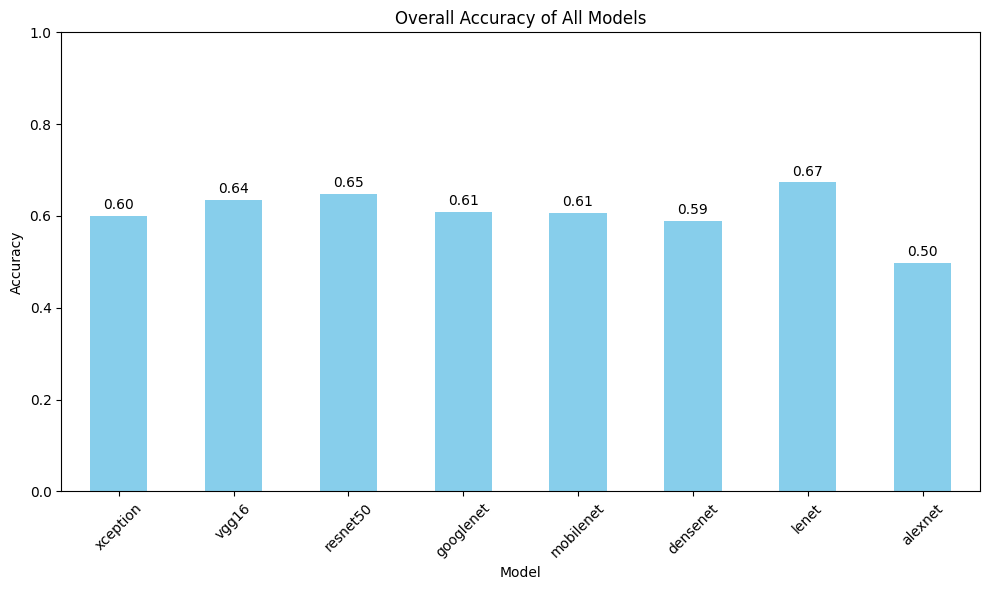

<Figure size 1000x600 with 0 Axes>

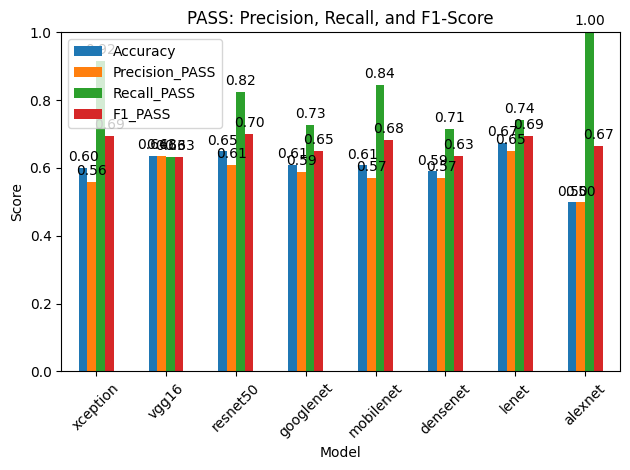

<Figure size 1000x600 with 0 Axes>

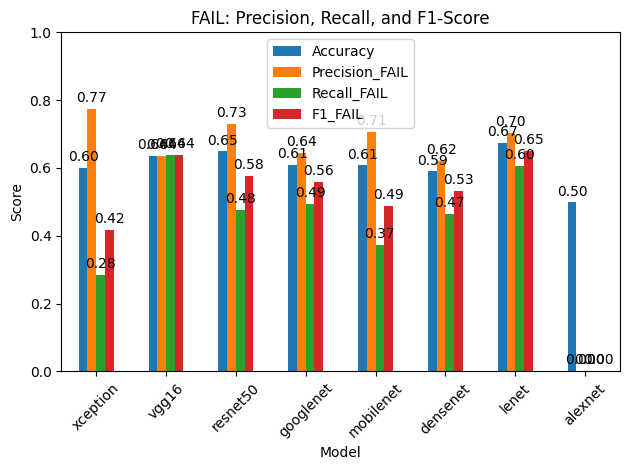

In [21]:
# Function to annotate bars with values
def annotate_bars(ax):
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5), 
                    textcoords='offset points')

# Function to plot PASS, FAIL, and overall accuracy in separate charts with bar values
def plot_separate_metrics(metrics_df):
    # metrics_df.set_index('Model', inplace=True)
    
    # Plot accuracy
    plt.figure(figsize=(10, 6))
    ax = metrics_df['Accuracy'].plot(kind='bar', color='skyblue', ylim=(0, 1))
    plt.title('Overall Accuracy of All Models')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=45)
    annotate_bars(ax)  # Annotate the bars with numbers
    plt.tight_layout()
    plt.show()

    # Plot precision, recall, and F1 for PASS class
    plt.figure(figsize=(10, 6))
    ax = metrics_df[['Accuracy','Precision_PASS', 'Recall_PASS', 'F1_PASS']].plot(kind='bar', ylim=(0, 1))
    plt.title('PASS: Precision, Recall, and F1-Score')
    plt.ylabel('Score')
    plt.xticks(rotation=45)
    annotate_bars(ax)  # Annotate the bars with numbers
    plt.tight_layout()
    plt.show()

    # Plot precision, recall, and F1 for FAIL class
    plt.figure(figsize=(10, 6))
    ax = metrics_df[['Accuracy','Precision_FAIL', 'Recall_FAIL', 'F1_FAIL']].plot(kind='bar', ylim=(0, 1))
    plt.title('FAIL: Precision, Recall, and F1-Score')
    plt.ylabel('Score')
    plt.xticks(rotation=45)
    annotate_bars(ax)  # Annotate the bars with numbers
    plt.tight_layout()
    plt.show()

# Call the function to plot separate charts with values on bars
plot_separate_metrics(metrics_df)


In [2]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np
import os

# Define directories and dataset settings
MODELS = ['xception', 'vgg16', 'resnet50', 'googlenet', 'mobilenet', 'densenet', 'lenet', 'alexnet']

# Directories for datasets
train_dir = "img_bk/train"
val_dir = "img_bk/validate"
test_dir = "img_bk/test"
IMG_SIZE = (224, 224)  # Adjust image size as per model requirements
BATCH_SIZE = 32  # Adjust batch size as per model and memory capabilities

# Load test dataset
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

# Retrieve class names directly from the dataset
class_names = test_dataset.class_names

# Cache and prefetch test dataset for performance
AUTOTUNE = tf.data.AUTOTUNE
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# Function to get true labels and predictions
def get_predictions_and_labels(model):
    true_labels = []
    predictions = []

    for images, labels in test_dataset:
        true_labels.extend(labels.numpy())
        preds = model.predict(images)
        predictions.extend((preds > 0.5).astype(int).flatten())  # Binary classification threshold

    return np.array(true_labels), np.array(predictions)

# Metrics storage for each model
model_metrics = {
    'accuracy': {},
    'precision_class_0': {},
    'precision_class_1': {},
    'recall_class_0': {},
    'recall_class_1': {},
    'f1-score_class_0': {},
    'f1-score_class_1': {},
    'precision_overall': {},
    'recall_overall': {},
    'f1-score_overall': {}
}

# Loop over each model, load it, evaluate, and store metrics
for model_name in MODELS:
    model_file = f'{model_name}_model_all_2class_img_bk.h5'  # Path to saved model file
    if os.path.exists(model_file):
        print(f"\nLoading {model_name}...")
        model = load_model(model_file)
        
        # Get predictions and true labels
        true_labels, predictions = get_predictions_and_labels(model)
        
        # Classification report
        report = classification_report(true_labels, predictions, target_names=class_names, output_dict=True)
        
        # Store accuracy, precision, recall, and F1-score for each class and overall
        model_metrics['accuracy'][model_name] = report['accuracy']
        model_metrics['precision_class_0'][model_name] = report[class_names[0]]['precision']
        model_metrics['precision_class_1'][model_name] = report[class_names[1]]['precision']
        model_metrics['recall_class_0'][model_name] = report[class_names[0]]['recall']
        model_metrics['recall_class_1'][model_name] = report[class_names[1]]['recall']
        model_metrics['f1-score_class_0'][model_name] = report[class_names[0]]['f1-score']
        model_metrics['f1-score_class_1'][model_name] = report[class_names[1]]['f1-score']
        
        # Store overall (macro avg) metrics
        model_metrics['precision_overall'][model_name] = report['macro avg']['precision']
        model_metrics['recall_overall'][model_name] = report['macro avg']['recall']
        model_metrics['f1-score_overall'][model_name] = report['macro avg']['f1-score']
    else:
        print(f"Model file {model_file} not found!")

# Function to plot comparison charts for different metrics
def plot_comparison_chart(metric_name, metric_values):
    plt.figure(figsize=(10, 6))
    plt.bar(list(metric_values.keys()), list(metric_values.values()), color='skyblue')
    plt.ylabel(metric_name)
    plt.title(f'Comparison of {metric_name.capitalize()} Across Models')
    plt.ylim(0, 1)  # For better visual scale of metrics
    
    # Add value labels to bars
    for i, v in enumerate(metric_values.values()):
        plt.text(i, v, f"{v:.4f}", color='blue', ha='center', va='bottom')
    
    plt.show()

# Plot charts for each metric and class
# plot_comparison_chart('Accuracy', model_metrics['accuracy'])
# plot_comparison_chart('Precision (Class 0)', model_metrics['precision_class_0'])
# plot_comparison_chart('Precision (Class 1)', model_metrics['precision_class_1'])
# plot_comparison_chart('Recall (Class 0)', model_metrics['recall_class_0'])
# plot_comparison_chart('Recall (Class 1)', model_metrics['recall_class_1'])
# plot_comparison_chart('F1-score (Class 0)', model_metrics['f1-score_class_0'])
# plot_comparison_chart('F1-score (Class 1)', model_metrics['f1-score_class_1'])
# plot_comparison_chart('Overall Precision', model_metrics['precision_overall'])
# plot_comparison_chart('Overall Recall', model_metrics['recall_overall'])
# plot_comparison_chart('Overall F1-score', model_metrics['f1-score_overall'])


Found 1477 files belonging to 2 classes.

Loading xception...
1/1 [==============================] - 1s 562ms/step

Loading vgg16...
1/1 [==============================] - 2s 2s/step

Loading resnet50...
1/1 [==============================] - 1s 724ms/step

Loading googlenet...
1/1 [==============================] - 1s 1s/step

Loading mobilenet...
1/1 [==============================] - 1s 563ms/step

Loading densenet...
1/1 [==============================] - 1s 1s/step

Loading lenet...
1/1 [==============================] - 0s 162ms/step

Loading alexnet...
1/1 [==============================] - 0s 391ms/step


c:\Users\1000305259\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\1000305259\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\1000305259\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_

In [35]:
import matplotlib.pyplot as plt

def plot_comparison_chart(metric_name, metric_values):
    plt.figure(figsize=(10, 6))
    
    # Define colors for each bar, setting the second bar to a different color
    bar_colors = ['gray' if i != 2 else 'blue' for i in range(len(metric_values))]
    
    plt.bar(list(metric_values.keys()), list(metric_values.values()), color=bar_colors)
    plt.ylabel(metric_name)
    plt.title(f'Comparison of {metric_name.capitalize()} Across Models')
    plt.ylim(0, 1)  # For better visual scale of metrics
    
    # Add value labels to bars
    for i, v in enumerate(metric_values.values()):
        if i == 2:
            plt.text(i, v, f"{v:.4f}", color='red', ha='center', va='bottom', fontsize=14, weight='bold')
        else:
            plt.text(i, v, f"{v:.4f}", color='black', ha='center', va='bottom', fontsize=10)
    
    plt.show()


In [38]:
# Plot charts for each metric and class
plot_comparison_chart('Accuracy', model_metrics['precision_class_0','precision_class_1'])
# plot_comparison_chart('Precision (Class 0)', model_metrics['precision_class_0'])
# plot_comparison_chart('Precision (Class 1)', model_metrics['precision_class_1'])
# plot_comparison_chart('Recall (Class 0)', model_metrics['recall_class_0'])
# plot_comparison_chart('Recall (Class 1)', model_metrics['recall_class_1'])
# plot_comparison_chart('F1-score (Class 0)', model_metrics['f1-score_class_0'])
# plot_comparison_chart('F1-score (Class 1)', model_metrics['f1-score_class_1'])
# plot_comparison_chart('Overall Precision', model_metrics['precision_overall'])
# plot_comparison_chart('Overall Recall', model_metrics['recall_overall'])
# plot_comparison_chart('Overall F1-score', model_metrics['f1-score_overall'])

KeyError: ('precision_class_0', 'precision_class_1')

In [4]:
import pandas as pd

In [5]:
pd.DataFrame(model_metrics)

,accuracy,precision_class_0,precision_class_1,recall_class_0,recall_class_1,f1-score_class_0,f1-score_class_1,precision_overall,recall_overall,f1-score_overall
xception,0.599865,0.560166,0.775735,0.917120,0.284750,0.695518,0.416584,0.667951,0.600935,0.556051
vgg16,0.635748,0.634877,0.636608,0.633152,0.638327,0.634014,0.637466,0.635743,0.635739,0.635740
resnet50,0.648612,0.609045,0.730290,0.823370,0.475034,0.700173,0.575634,0.669668,0.649202,0.637903
googlenet,0.607312,0.585526,0.642478,0.725543,0.489879,0.648058,0.555896,0.614002,0.607711,0.601977
mobilenet,0.607312,0.571823,0.705882,0.843750,0.372470,0.681668,0.487633,0.638853,0.608110,0.584651
densenet,0.589709,0.570499,0.621622,0.714674,0.465587,0.634499,0.532407,0.596060,0.590130,0.583453
lenet,0.672986,0.650775,0.702194,0.741848,0.604588,0.693333,0.649746,0.676485,0.673218,0.671540
alexnet,0.498307,0.498307,0.000000,1.000000,0.000000,0.665160,0.000000,0.249154,0.500000,0.332580


In [6]:
pd.DataFrame(model_metrics).reset_index()

,index,accuracy,precision_class_0,precision_class_1,recall_class_0,recall_class_1,f1-score_class_0,f1-score_class_1,precision_overall,recall_overall,f1-score_overall
0,xception,0.599865,0.560166,0.775735,0.917120,0.284750,0.695518,0.416584,0.667951,0.600935,0.556051
1,vgg16,0.635748,0.634877,0.636608,0.633152,0.638327,0.634014,0.637466,0.635743,0.635739,0.635740
2,resnet50,0.648612,0.609045,0.730290,0.823370,0.475034,0.700173,0.575634,0.669668,0.649202,0.637903
3,googlenet,0.607312,0.585526,0.642478,0.725543,0.489879,0.648058,0.555896,0.614002,0.607711,0.601977
4,mobilenet,0.607312,0.571823,0.705882,0.843750,0.372470,0.681668,0.487633,0.638853,0.608110,0.584651
5,densenet,0.589709,0.570499,0.621622,0.714674,0.465587,0.634499,0.532407,0.596060,0.590130,0.583453
6,lenet,0.672986,0.650775,0.702194,0.741848,0.604588,0.693333,0.649746,0.676485,0.673218,0.671540
7,alexnet,0.498307,0.498307,0.000000,1.000000,0.000000,0.665160,0.000000,0.249154,0.500000,0.332580


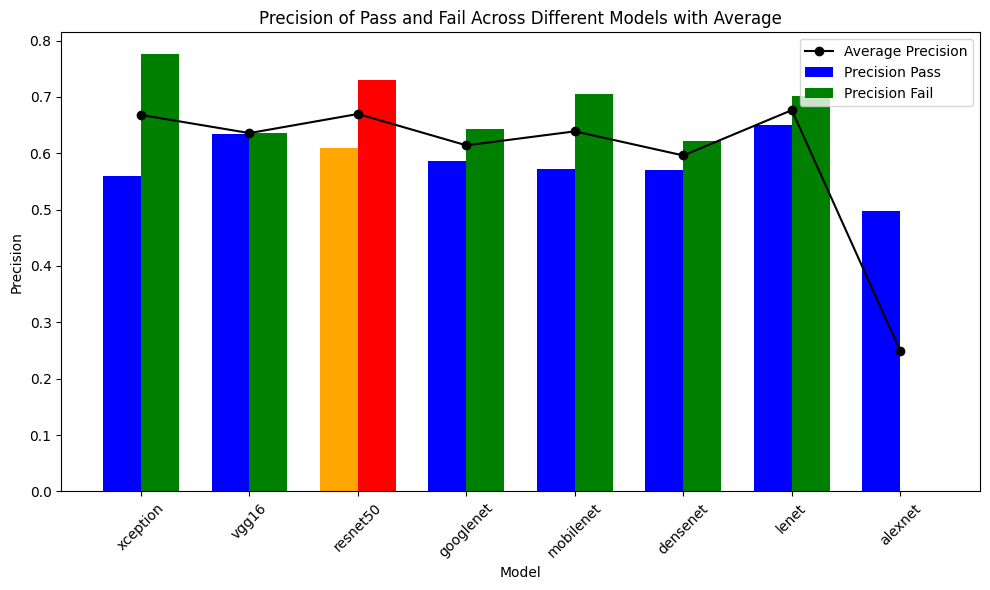

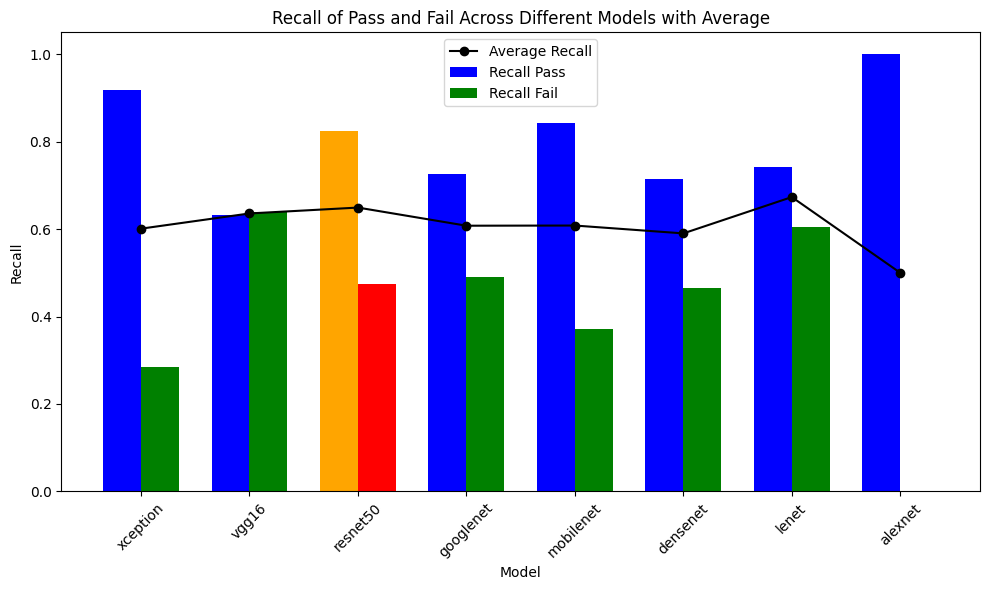

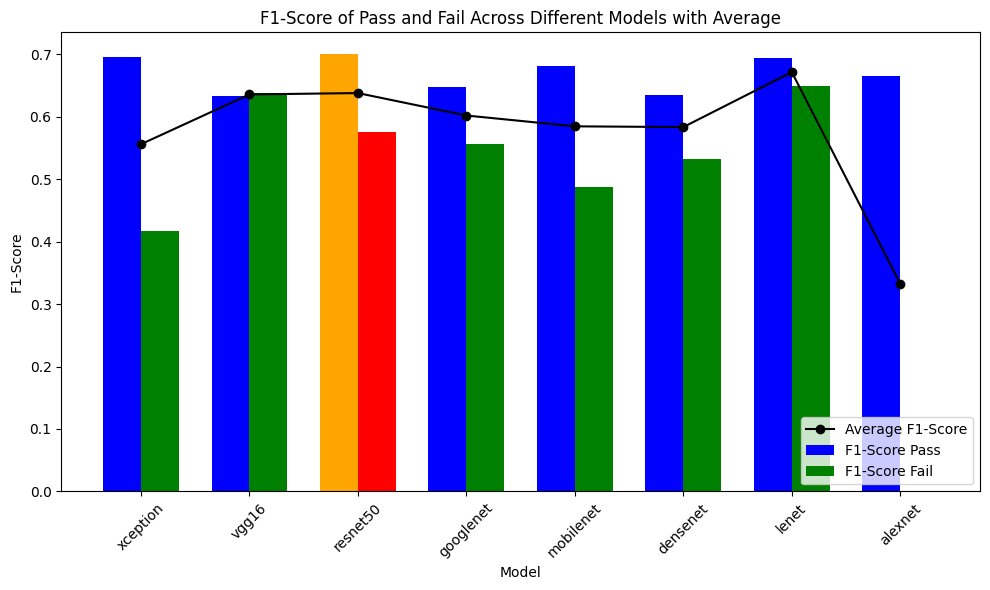

In [13]:
import matplotlib.pyplot as plt
import numpy as np


df = pd.DataFrame(model_metrics).reset_index()
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data setup
# data = {
#     'Model': ['xception', 'vgg16', 'resnet50', 'googlenet', 'mobilenet', 'densenet', 'lenet', 'alexnet'],
#     'precision_class_0': [0.560166, 0.634014, 0.609045, 0.587004, 0.571823, 0.570499, 0.650775, 0.498307],
#     'precision_class_1': [0.775735, 0.636119, 0.730290, 0.643234, 0.705882, 0.621622, 0.702194, 0.000000],
#     'recall_class_0': [0.917120, 0.633152, 0.823370, 0.724185, 0.843750, 0.714674, 0.741848, 1.000000],
#     'recall_class_1': [0.284750, 0.636977, 0.475034, 0.493927, 0.372470, 0.465587, 0.604588, 0.000000],
#     'f1-score_class_0': [0.695518, 0.633583, 0.700173, 0.648418, 0.681668, 0.634499, 0.693333, 0.665160],
#     'f1-score_class_1': [0.416584, 0.636548, 0.575634, 0.558779, 0.487633, 0.532407, 0.649746, 0.000000]
# }
# df = pd.DataFrame(data)

# Define bar width and position
bar_width = 0.35
index = np.arange(len(df['index']))
resnet50_index = 'resnet50'  # Locate the index of 'resnet50' model

# Colors for ResNet50 and other models
colors_pass = ['orange' if i == 2 else 'blue' for i in range(len(df['index']))]
colors_fail = ['red' if i == 2 else 'green' for i in range(len(df['index']))]

# Adding average columns for each metric
df['precision_avg'] = df[['precision_class_0', 'precision_class_1']].mean(axis=1)
df['recall_avg'] = df[['recall_class_0', 'recall_class_1']].mean(axis=1)
df['f1_score_avg'] = df[['f1-score_class_0', 'f1-score_class_1']].mean(axis=1)

# Precision Plot with Average
plt.figure(figsize=(10, 6))
plt.bar(index, df['precision_class_0'], bar_width, color=colors_pass, label='Precision Pass')
plt.bar(index + bar_width, df['precision_class_1'], bar_width, color=colors_fail, label='Precision Fail')
plt.plot(index + bar_width / 2, df['precision_avg'], marker='o', color='black', label='Average Precision')
plt.xlabel('Model')
plt.ylabel('Precision')
plt.title('Precision of Pass and Fail Across Different Models with Average')
plt.xticks(index + bar_width / 2, df['index'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Recall Plot with Average
plt.figure(figsize=(10, 6))
plt.bar(index, df['recall_class_0'], bar_width, color=colors_pass, label='Recall Pass')
plt.bar(index + bar_width, df['recall_class_1'], bar_width, color=colors_fail, label='Recall Fail')
plt.plot(index + bar_width / 2, df['recall_avg'], marker='o', color='black', label='Average Recall')
plt.xlabel('Model')
plt.ylabel('Recall')
plt.title('Recall of Pass and Fail Across Different Models with Average')
plt.xticks(index + bar_width / 2, df['index'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# F1-Score Plot with Average
plt.figure(figsize=(10, 6))
plt.bar(index, df['f1-score_class_0'], bar_width, color=colors_pass, label='F1-Score Pass')
plt.bar(index + bar_width, df['f1-score_class_1'], bar_width, color=colors_fail, label='F1-Score Fail')
plt.plot(index + bar_width / 2, df['f1_score_avg'], marker='o', color='black', label='Average F1-Score')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.title('F1-Score of Pass and Fail Across Different Models with Average')
plt.xticks(index + bar_width / 2, df['index'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

